# Diffusion-LLM Entropy Framework — Analysis & Corrected Extraction

## 1. Which heatmap is the "correct representation"?

**Both** notebooks draw the *same* heatmap, and the representation is a reasonable one:

```python
heatmap_data = df.pivot(index='canvas_position',
                        columns='denoising_step',
                        values='prediction_entropy')
sns.heatmap(heatmap_data, cmap="viridis", ...)
```

Rows = token position in the generated block, columns = denoising step, colour =
per-token vocabulary entropy. It is a **legitimate but not canonical** way to
visualise how a diffusion LM's uncertainty collapses over its denoising trajectory,
and it matches the project plan's "entropy across denoising steps / entropy drop
per token" goal. **Key caveat:** both notebooks take entropy over *every* canvas
position at *every* forward pass — including positions already committed, which
re-encode a known token at ~0 entropy — so the picture largely encodes **commit
order**, not pure per-token difficulty. The mask-aware variant in this rewrite is
what fixes that.

Between the two, the **`Framework (Diffusion).ipynb` heatmap is the better of the
two**, but for a narrower reason than it looks:
- The heatmaps render **only** `prediction_entropy`, so the MoE-router change
  (optional vs. mandatory) has **no effect on the heatmap** — it only feeds the
  separate router scatter plot. Router-optionality matters for the framework's
  *generality*, not for this image.
- The single heatmap-relevant code difference is the Framework extractor's
  `prediction_logits.pop(0)`, which drops the prompt-evaluation ("prefill") pass so
  step 0 is the first real denoising step. (That `pop(0)` is itself model-specific
  and is actually *wrong* for reference LLaDA/Dream, which have no prefill pass —
  see §2, row 5.)
- The two rendered images also differ simply because they were run on **different
  WikiText inputs/prompts**, so their values and step counts aren't directly
  comparable.

So **neither extraction is correct or general as written.** The heatmap *shape*
is fine; the *data pipeline* behind it is what needs fixing.

## 2. What is wrong with the extraction (not the picture)

| # | Problem | Where | Why it's wrong |
|---|---------|-------|----------------|
| 1 | Fictional model `DiffusionGemmaForBlockDiffusion` / `google/diffusiongemma-26B-A4B-it` | both | No such class or checkpoint exists — neither notebook ever ran on a real diffusion LLM. The project actually targets **LLaDA** and **MDLM/masked-diffusion** models. |
| 2 | Assumes Mixture-of-Experts router; Week8_3 **raises** if no `.gate`/`.router` found, and does `raw_router_logits.view(canvas_size, num_experts)` | both, esp. Week8_3 | The real targets **LLaDA-8B and Dream-7B are DENSE** (no router). Week8_3's extractor would crash on them. Router capture must be optional. |
| 3 | Manual loop initializes the canvas with `torch.randint` random token IDs and re-decides **all** positions every step (`current_input_ids[0, prompt_len:] = top_token_ids_t`) | Week8_3 cell 1 | Two precise faults: (a) masked diffusion must init the unknown region to the **`[MASK]` id**, not random tokens (random init belongs to uniform/D3PM diffusion); (b) committed tokens must be **frozen**, unmasking only a subset per step. The bug is the random init + no freezing — *not* the use of argmax (greedy selection is legitimate). Self-declared broken in the notebook. |
| 4 | The stated *reason* for that bug — "diffusion denoises continuous latent embeddings, not discrete IDs" | Week8_3 markdown | **Factually wrong** for the dominant open diffusion LLMs. LLaDA, Dream, MDLM, SEDD are **discrete masked-token** diffusion over token IDs with a `[MASK]` state. (Continuous-latent diffusion — Diffusion-LM, Plaid — is a different, minority family.) The loop is broken for *scheduling* reasons, not because of continuous latents. |
| 5 | `logits[0, -canvas_size:, :]` + "one forward pass == one step" + `pop(0)` | both hook extractors | Model-specific assumptions. They break under KV-caching (per-step logits may cover only new positions), block/semi-AR decoding (canvas grows), or a custom `diffusion_generate()`. |
| 6 | Entropy computed at **every** position **every** step, including frozen and not-yet-reached masked slots | both | Conflates three quantities: (a) genuine uncertainty of a masked-and-being-decided token — the signal you want; (b) a frozen token re-encoded (~0 entropy, exactly 0 under SUBS-parameterised MDMs); (c) a not-yet-reached masked slot, which is confounded in **both** directions — often artificially *low* (mass piling on **`<eos>`/`<pad>`**; note well-trained MDMs suppress the `<mask>` logit, so mask itself isn't the attractor) or artificially *high* (missing local context). Fix: track mask state and restrict/annotate entropy to still-masked positions; optionally exclude `<eos>/<pad>` from the entropy support. |

## 3. The correct, general extraction

Isolate everything model-specific in a small `DiffusionModelSpec` adapter, then use
a framework-owned denoising loop so step index, mask state, and the predictive
distribution are all exact:

- **Backend A — `run_controlled_denoising`** (recommended): reimplements the
  masked-diffusion sampler (a faithful generalisation of LLaDA's official loop),
  computing entropy on the model's distribution at masked positions **before**
  they are committed, and recording `is_masked` / `committed_at_step` per token.
- **Backend B — `capture_via_hooks`** (fallback): hardened version of the
  notebooks' passive-hook method for when you can only call the model's native
  `generate()`/`diffusion_generate()`. Router optional; canvas width and step
  count derived from what's captured; robust prefill filter instead of `pop(0)`.

The heatmap is unchanged in spirit but gains a `mask_aware=True` option that blanks
cells after a token is committed, so the colour reflects real
uncertainty-while-undecided.

Every user-editable point is marked `>>> CUSTOMIZE` in the code, and presets are
provided for LLaDA (`spec_for_llada`) and Dream (`spec_for_dream`).


In [1]:
"""
=====================================================================================
 UNIVERSAL DIFFUSION-LLM TOKEN-ENTROPY FRAMEWORK
=====================================================================================
 Measures per-token uncertainty (entropy) across the denoising steps of ANY
 diffusion language model and renders the canonical "denoising heatmap"
 (token position x denoising step x prediction entropy).

 WHY THIS REWRITE EXISTS
 -----------------------
 The two original notebooks (`Framework (Diffusion).ipynb`, `Week8_3.ipynb`) both
 draw the SAME heatmap:

     df.pivot(index='canvas_position', columns='denoising_step',
              values='prediction_entropy')   ->   sns.heatmap(...)

 That *representation* is correct and is kept here. What was NOT correct / not
 general was the *extraction* that feeds it. Concretely, the originals:

   (1) Targeted a model that does not exist (`DiffusionGemmaForBlockDiffusion`,
       `google/diffusiongemma-26B-A4B-it`), so neither notebook was ever run
       against a real diffusion LLM.
   (2) Assumed a Mixture-of-Experts router (`.gate`/`.router`) and in Week8_3
       RAISE an error when none is found. The real open diffusion LLMs this
       project targets -- LLaDA-8B and Dream-7B -- are DENSE, so that code path
       cannot run on them. Router capture must be OPTIONAL.
   (3) Captured logits by hooking `lm_head` under a generic `model.generate()`
       and then slicing `logits[0, -canvas_size:, :]`, treating "one forward
       pass == one denoising step" and `pop(0)` == "the prefill pass". Those
       assumptions are model-specific and silently break under KV-caching,
       block / semi-autoregressive decoding, or a custom `diffusion_generate()`.
   (4) Week8_3's first extractor additionally OVERWROTE every canvas position
       with a hard argmax each step -- that is not a valid denoising schedule
       (real masked diffusion commits only a confident SUBSET per step). The
       notebook's own explanation for the bug ("diffusion denoises continuous
       latent embeddings, not discrete IDs") is itself wrong for LLaDA/Dream/
       MDLM/SEDD, which ARE discrete masked-token diffusion.

 THE FIX (this file)
 -------------------
 A tiny per-model ADAPTER (`DiffusionModelSpec`) isolates everything that is
 model-specific. Two extraction backends consume it:

   * Backend A -- `run_controlled_denoising`  [RECOMMENDED / most correct]
       The framework owns the denoising loop, so it KNOWS the step<->pass
       mapping and the mask state of every position at every step, and it
       computes entropy on the model's predictive distribution at the masked
       positions BEFORE they are committed. This is a faithful generalization
       of the official LLaDA sampler and works for any discrete masked
       diffusion model.

   * Backend B -- `capture_via_hooks`  [FALLBACK]
       A hardened version of the notebooks' passive-hook approach, for models
       you can ONLY drive through their native generate()/diffusion_generate().
       Router capture is optional; the canvas slice and step count are derived
       from what is actually captured instead of being hard-coded.

 EVERY place a user must edit for their own model is marked with:  >>> CUSTOMIZE
=====================================================================================
"""

'\n=====================================================================================\n UNIVERSAL DIFFUSION-LLM TOKEN-ENTROPY FRAMEWORK\n=====================================================================================\n Measures per-token uncertainty (entropy) across the denoising steps of ANY\n diffusion language model and renders the canonical "denoising heatmap"\n (token position x denoising step x prediction entropy).\n\n WHY THIS REWRITE EXISTS\n -----------------------\n The two original notebooks (`Framework (Diffusion).ipynb`, `Week8_3.ipynb`) both\n draw the SAME heatmap:\n\n     df.pivot(index=\'canvas_position\', columns=\'denoising_step\',\n              values=\'prediction_entropy\')   ->   sns.heatmap(...)\n\n That *representation* is correct and is kept here. What was NOT correct / not\n general was the *extraction* that feeds it. Concretely, the originals:\n\n   (1) Targeted a model that does not exist (`DiffusionGemmaForBlockDiffusion`,\n       `google/diffusio

In [2]:
# =====================================================================================
# 0. IMPORTS
# =====================================================================================
from __future__ import annotations

import math
from dataclasses import dataclass, field
from typing import Callable, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

/home/ubuntu/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# =====================================================================================
# 1. ENTROPY ENGINE  (model-agnostic -- never needs editing)
# =====================================================================================
class EntropyEngine:
    """
    Shannon entropy and confidence of a categorical distribution given raw logits.

        H(p) = -sum_v p_v * log p_v          (natural log -> units of 'nats')

    `logits` may be any shape [..., num_classes]; the last dim is the vocabulary
    (for token entropy) or the experts (for MoE router entropy). Computed in
    float32 for numerical stability regardless of the model dtype (bf16/fp16).
    """

    @staticmethod
    def compute(logits: torch.Tensor, exclude_ids: Optional[list[int]] = None):
        logits = logits.float()
        if exclude_ids:
            # Optionally remove structural tokens (typically EOS / PAD, and MASK)
            # from the support BEFORE softmax. In well-trained masked diffusion models
            # the <mask> logit is suppressed, so the real "artificially low entropy"
            # attractor for not-yet-decoded positions is EOS/PAD -- excluding them
            # gives a cleaner semantic-uncertainty signal.
            logits = logits.clone()
            logits[..., exclude_ids] = -float("inf")
        log_probs = F.log_softmax(logits, dim=-1)
        probs = log_probs.exp()
        entropy = -(probs * log_probs).sum(dim=-1)          # [...]
        top_confidence, top_ids = probs.max(dim=-1)         # [...]
        # Margin between the top-2 classes -- a second, often-cleaner difficulty signal.
        top2 = probs.topk(2, dim=-1).values if probs.shape[-1] >= 2 else None
        margin = (top2[..., 0] - top2[..., 1]) if top2 is not None else torch.zeros_like(top_confidence)
        return {
            "entropy": entropy,
            "top_confidence": top_confidence,
            "top_ids": top_ids,
            "margin": margin,
        }

    @staticmethod
    def normalized(entropy: torch.Tensor, num_classes: int) -> torch.Tensor:
        """Entropy in [0, 1] (divide by log(num_classes)) so heatmaps are comparable
        ACROSS models with different vocab sizes -- important for cross-architecture work."""
        return entropy / math.log(num_classes)

In [4]:
# =====================================================================================
# 2. THE PER-MODEL ADAPTER   >>> CUSTOMIZE FOR YOUR MODEL <<<
# =====================================================================================
@dataclass
class DiffusionModelSpec:
    """
    Everything that differs between diffusion LLMs lives here. To support a new
    model you fill in this struct -- you should NOT need to touch the extraction
    or plotting code below.

    >>> CUSTOMIZE every field marked below for your model. Presets for LLaDA and
        Dream are provided by `spec_for_llada()` / `spec_for_dream()`.
    """

    name: str

    # --- The masking / canvas definition (discrete masked diffusion) -------------
    # >>> CUSTOMIZE: the id of the [MASK] / absorbing token. LLaDA = 126336.
    #     Dream uses tokenizer.mask_token_id. Find it in the model's tokenizer or
    #     generation_config (look for `mask_token_id`).
    mask_token_id: int = 0

    # >>> CUSTOMIZE: number of response tokens to generate (the "canvas" length).
    gen_length: int = 128

    # >>> CUSTOMIZE: number of denoising steps the sampler will run.
    num_steps: int = 128

    # >>> CUSTOMIZE: block size for semi-autoregressive decoding. Set == gen_length
    #     for pure (single-block) diffusion (e.g. plain LLaDA), or e.g. 32 for
    #     block/semi-AR decoding. Must divide gen_length.
    block_length: int = 128

    # >>> CUSTOMIZE: how positions are chosen to be committed each step.
    #     'low_confidence' = unmask the most confident masked positions (LLaDA /
    #     Dream default, "confidence"/"maskgit_plus"); 'random' = random order.
    remasking: str = "low_confidence"

    # >>> CUSTOMIZE: sampling temperature used to pick the committed token id.
    #     0.0 = greedy argmax (deterministic, best for analysis reproducibility).
    temperature: float = 0.0

    # >>> CUSTOMIZE (optional): token ids to EXCLUDE from the entropy calculation,
    #     typically [eos_id, pad_id] (and mask_id). Not-yet-decoded positions tend to
    #     pile mass on EOS/PAD, which deflates entropy without reflecting real
    #     uncertainty. Leave empty to keep raw full-vocab entropy; set it to measure
    #     "semantic" uncertainty over real words only.
    entropy_exclude_ids: list = field(default_factory=list)

    # --- How to get logits from ONE forward pass over the whole sequence ---------
    # >>> CUSTOMIZE (rarely): map a [1, seq] id tensor to a [seq, vocab] logits
    #     tensor. Default assumes a standard HF CausalLM-style `.logits`. Override
    #     if your model wraps its output differently or needs extra kwargs.
    forward_fn: Callable[["torch.nn.Module", torch.Tensor], torch.Tensor] = None

    # --- Optional MoE router capture (leave as-is for DENSE models) --------------
    # >>> CUSTOMIZE only for MoE diffusion models. Default matches nothing, so on a
    #     dense model (LLaDA, Dream) router capture is simply skipped -- no error.
    is_moe: bool = False
    router_name_filter: Callable[[str], bool] = lambda n: n.endswith(".gate") or n.endswith(".router")

    def __post_init__(self):
        if self.forward_fn is None:
            # Default forward: standard HuggingFace CausalLM. `logits` is [1, seq, vocab];
            # we return [seq, vocab] for the single batch element.
            def _default_forward(model, input_ids):
                out = model(input_ids)
                logits = out.logits if hasattr(out, "logits") else out[0]
                return logits[0]
            self.forward_fn = _default_forward
        if self.gen_length % self.block_length != 0:
            raise ValueError("block_length must divide gen_length")


# ---- Ready-made presets (verified against the official reference implementations) ----
def spec_for_llada(gen_length=128, steps=128, block_length=128, temperature=0.0) -> DiffusionModelSpec:
    """
    LLaDA-8B (GSAI-ML/LLaDA-8B-Instruct / -Base). Dense masked diffusion.
    Load with:
        from transformers import AutoModel, AutoTokenizer
        tok   = AutoTokenizer.from_pretrained('GSAI-ML/LLaDA-8B-Instruct', trust_remote_code=True)
        model = AutoModel.from_pretrained('GSAI-ML/LLaDA-8B-Instruct',
                                          trust_remote_code=True, torch_dtype=torch.bfloat16).cuda().eval()
    The official sampler uses mask_id=126336 and a plain `model(x).logits` forward
    with NO KV cache (full sequence re-encoded each step) -- exactly the assumption
    our controlled loop needs.
    """
    return DiffusionModelSpec(
        name="LLaDA-8B",
        mask_token_id=126336,          # verified: LLaDA reserved [MASK] id
        gen_length=gen_length,
        num_steps=steps,
        block_length=block_length,
        remasking="low_confidence",
        temperature=temperature,
        is_moe=False,
    )


def spec_for_dream(tokenizer, gen_length=128, steps=128, temperature=0.0) -> DiffusionModelSpec:
    """
    Dream-7B (Dream-org/Dream-v0-Instruct-7B). Dense masked diffusion built on a
    Qwen2.5 backbone. Dream ships its OWN sampler `model.diffusion_generate(...)`
    (NOT HF `.generate()`), so the recommended path for Dream is Backend C:
    call `diffusion_generate(..., output_history=True, return_dict_in_generate=True)`
    and pass `out.history` to `capture_via_token_history`. If you instead drive it
    with the controlled loop (Backend A), the mask id is the tokenizer's mask token.
    """
    mask_id = getattr(tokenizer, "mask_token_id", None)
    if mask_id is None:
        raise ValueError("Dream tokenizer has no mask_token_id; set spec.mask_token_id manually.")
    return DiffusionModelSpec(
        name="Dream-7B",
        mask_token_id=mask_id,
        gen_length=gen_length,
        num_steps=steps,
        block_length=gen_length,       # Dream default is single-block full-diffusion
        remasking="low_confidence",
        temperature=temperature,
        is_moe=False,
    )

In [5]:
# =====================================================================================
# 3. HELPERS FOR THE CONTROLLED DENOISING LOOP
# =====================================================================================
def _add_gumbel_noise(logits: torch.Tensor, temperature: float) -> torch.Tensor:
    """Gumbel-max trick for temperature sampling. temperature==0 -> pure argmax.
    (float64 as in the LLaDA reference to avoid low-precision ties.)"""
    if temperature == 0.0:
        return logits
    logits = logits.to(torch.float64)
    noise = torch.rand_like(logits)
    gumbel = -torch.log(-torch.log(noise + 1e-20) + 1e-20)
    return logits + temperature * gumbel


def _num_transfer_per_step(num_masked: int, steps: int) -> list[int]:
    """Spread `num_masked` commits as evenly as possible over `steps` (LLaDA-style
    linear schedule). Returns a list of length `steps` summing to num_masked."""
    base = num_masked // steps
    remainder = num_masked % steps
    counts = [base] * steps
    for i in range(remainder):
        counts[i] += 1
    return counts

In [6]:
# =====================================================================================
# 4. BACKEND A -- CONTROLLED DENOISING LOOP  [RECOMMENDED / MOST CORRECT]
# =====================================================================================
@torch.no_grad()
def run_controlled_denoising(model, tokenizer, prompt_ids: torch.Tensor,
                             spec: DiffusionModelSpec) -> pd.DataFrame:
    """
    Own the denoising loop so that step index, mask state, and the predictive
    distribution are all EXACT (not inferred from hook timing).

    Correctness properties this guarantees, which the hook approach could not:
      * `denoising_step` is the true sampler step (1 forward pass == 1 step here).
      * `is_masked` records whether a position was STILL masked at that step, so
        entropy is attributable to genuine token uncertainty rather than to a
        frozen token being re-encoded (~0 entropy) or a far-future masked slot
        collapsing onto <mask>/<pad>/<eos>.
      * `prediction_entropy` is measured on the model's distribution at that
        position BEFORE the commit, i.e. the uncertainty the sampler actually
        resolved.

    Returns a tidy DataFrame (one row per gen position per step).
    """
    device = model.device
    prompt_ids = prompt_ids.to(device)
    prompt_len = prompt_ids.shape[1]
    seq_len = prompt_len + spec.gen_length
    mask_id = spec.mask_token_id

    # Build the canvas: [prompt | MASK * gen_length]
    x = torch.full((1, seq_len), mask_id, dtype=torch.long, device=device)
    x[:, :prompt_len] = prompt_ids

    # Optional MoE router capture (skipped automatically for dense models).
    captured_router = {}
    router_handle = None
    if spec.is_moe:
        router_module = None
        for n, m in model.named_modules():
            if spec.router_name_filter(n):
                router_module = m            # keep the LAST match (final layer)
        if router_module is not None:
            def _router_hook(module, args, output):
                captured_router["logits"] = (output[0] if isinstance(output, tuple) else output).detach()
            router_handle = router_module.register_forward_hook(_router_hook)

    num_blocks = spec.gen_length // spec.block_length
    steps_per_block = max(1, spec.num_steps // num_blocks)

    records = []
    prev_entropy: dict[int, float] = {}
    prev_pred: dict[int, int] = {}
    committed_at: dict[int, Optional[int]] = {j: None for j in range(spec.gen_length)}

    global_step = 0
    try:
        for b in range(num_blocks):
            blk_lo = prompt_len + b * spec.block_length
            blk_hi = prompt_len + (b + 1) * spec.block_length
            n_masked_block = int((x[0, blk_lo:blk_hi] == mask_id).sum().item())
            schedule = _num_transfer_per_step(n_masked_block, steps_per_block)

            for s in range(steps_per_block):
                mask_index = (x == mask_id)                                  # [1, seq]

                # ---- ONE forward pass; entropy on the RAW logits, all gen positions ----
                # Use RAW (un-noised, un-warped) logits for entropy -- this is the same
                # distribution LLaDA/Dream score confidence on, not the gumbel/temperature
                # sampling logits.
                logits = spec.forward_fn(model, x)                           # [seq, vocab]
                gen_logits = logits[prompt_len:]                             # [gen_length, vocab]
                stats = EntropyEngine.compute(gen_logits, exclude_ids=spec.entropy_exclude_ids)
                entropy = stats["entropy"].cpu()
                conf = stats["top_confidence"].cpu()
                pred_ids = stats["top_ids"]
                margin = stats["margin"].cpu()

                # ---- Router entropy (optional) ----
                router_entropy_vec = None
                if spec.is_moe and "logits" in captured_router:
                    r = captured_router["logits"]
                    if r.dim() == 2:
                        r = r.view(1, -1, r.shape[-1])
                    router_entropy_vec = EntropyEngine.compute(r[0, prompt_len:])["entropy"].cpu()

                # ---- Decide which masked positions to commit this step ----
                # Sampled token id per position (temperature via Gumbel; 0 -> argmax).
                # This mirrors LLaDA: the commit ORDER uses top-1 softmax confidence
                # (== prob of the argmax token at temperature 0), highest first.
                sampled_ids = _add_gumbel_noise(gen_logits, spec.temperature).argmax(dim=-1)  # [gen_length]
                block_mask_local = mask_index[0, blk_lo:blk_hi]                                # [block_length]
                block_conf = conf.to(device)[b * spec.block_length:(b + 1) * spec.block_length]  # [block_length]
                neg_inf = torch.full_like(block_conf, -float("inf"))

                if spec.remasking == "low_confidence":
                    order_score = torch.where(block_mask_local, block_conf, neg_inf)
                else:  # 'random'
                    order_score = torch.where(block_mask_local,
                                              torch.rand(spec.block_length, device=device), neg_inf)

                k = min(schedule[s], int(block_mask_local.sum().item()))
                commit_local = torch.zeros(spec.block_length, dtype=torch.bool, device=device)
                if k > 0:
                    top_idx = torch.topk(order_score, k).indices
                    commit_local[top_idx] = True

                # ---- Record one row per gen position (BEFORE applying the commit) ----
                entropy_l = entropy.tolist()
                conf_l = conf.tolist()
                margin_l = margin.tolist()
                pred_l = pred_ids.cpu().tolist()
                router_l = router_entropy_vec.tolist() if router_entropy_vec is not None else None

                for j in range(spec.gen_length):
                    was_masked = bool(mask_index[0, prompt_len + j].item())
                    in_block = (blk_lo <= prompt_len + j < blk_hi)
                    commits_now = bool(in_block and commit_local[(prompt_len + j) - blk_lo].item())
                    cur_e = entropy_l[j]
                    cur_pred = pred_l[j]
                    if global_step > 0 and j in prev_entropy:
                        entropy_drop = prev_entropy[j] - cur_e
                        token_changed = (cur_pred != prev_pred[j])
                    else:
                        entropy_drop, token_changed = 0.0, False
                    prev_entropy[j] = cur_e
                    prev_pred[j] = cur_pred
                    if commits_now and committed_at[j] is None:
                        committed_at[j] = global_step

                    records.append({
                        "architecture": spec.name,
                        "denoising_step": global_step,
                        "canvas_position": j,
                        "prediction_entropy": cur_e,
                        "prediction_entropy_norm": cur_e / math.log(gen_logits.shape[-1]),
                        "router_entropy": (router_l[j] if router_l is not None else np.nan),
                        "entropy_drop": entropy_drop,
                        "top_confidence": conf_l[j],
                        "top2_margin": margin_l[j],
                        "predicted_token": tokenizer.decode([cur_pred]),
                        "is_masked": was_masked,          # still masked at this step?
                        "committed_this_step": commits_now,
                        "token_changed_from_prev_step": token_changed,
                    })

                # ---- Apply the commit: fill chosen masked slots with their sampled ids ----
                for local_pos in torch.nonzero(commit_local, as_tuple=False).flatten().tolist():
                    x[0, blk_lo + local_pos] = sampled_ids[(blk_lo + local_pos) - prompt_len]

                global_step += 1
    finally:
        if router_handle is not None:
            router_handle.remove()

    df = pd.DataFrame(records)
    # Attach each position's commit ("freeze") step -- handy for the aha-moment plot.
    df["committed_at_step"] = df["canvas_position"].map(committed_at).astype("float")
    return df

In [7]:
# =====================================================================================
# 5. BACKEND B -- PASSIVE HOOK CAPTURE UNDER NATIVE generate()  [FALLBACK]
# =====================================================================================
@torch.no_grad()
def capture_via_hooks(model, tokenizer, input_ids: torch.Tensor, spec: DiffusionModelSpec,
                      generate_kwargs: Optional[dict] = None) -> pd.DataFrame:
    """
    Use ONLY when you cannot reimplement the loop and must call the model's own
    generate()/diffusion_generate(). This hardens the notebooks' approach:

      * Router capture is OPTIONAL (dense models simply have no router rows).
      * The canvas width and step count are DERIVED from what is captured, not
        hard-coded; `pop(0)` is replaced by dropping only passes whose sequence
        length differs from the modal generation length (a robust prefill filter).
      * Each captured pass is checked for shape consistency before slicing.

    IMPORTANT limitations you must respect (these are intrinsic to hooking a
    black-box sampler, which is exactly why Backend A is preferred):
      - If the model uses a KV cache, per-step logits may cover only NEW positions;
        then there is no reliable "last canvas_size" slice and you should use the
        model's own per-step history instead (e.g. Dream's
        `diffusion_generate(..., output_history=True, return_dict_in_generate=True)`),
        or switch to Backend A.
      - This backend cannot know an exact per-position mask state, so `is_masked`
        is not produced here.

    >>> CUSTOMIZE `generate_kwargs` for your model's native sampler, e.g.
        LLaDA custom generate: not an HF .generate (use Backend A instead).
        Dream: {'max_new_tokens': gen_length, 'steps': num_steps, 'output_history': True,
                'return_dict_in_generate': True, 'alg': 'entropy'} via model.diffusion_generate.
    """
    device = model.device
    input_ids = input_ids.to(device)
    generate_kwargs = generate_kwargs or {"max_new_tokens": spec.gen_length}

    captured = {"pred": [], "router": []}

    def _lm_hook(module, args, output):
        logits = output[0] if isinstance(output, tuple) else output
        captured["pred"].append(logits.detach().float().cpu())

    def _router_hook(module, args, output):
        logits = output[0] if isinstance(output, tuple) else output
        captured["router"].append(logits.detach().float().cpu())

    # Locate LM head (works across HF models) and optional router.
    lm_head = model.get_output_embeddings()
    if lm_head is None and hasattr(model, "lm_head"):
        lm_head = model.lm_head
    if lm_head is None:
        raise ValueError("Could not locate the LM head via get_output_embeddings()/lm_head.")

    handles = [lm_head.register_forward_hook(_lm_hook)]
    if spec.is_moe:
        router_module = None
        for n, m in model.named_modules():
            if spec.router_name_filter(n):
                router_module = m
        if router_module is not None:
            handles.append(router_module.register_forward_hook(_router_hook))

    try:
        gen_fn = getattr(model, "diffusion_generate", model.generate)
        _ = gen_fn(input_ids, **generate_kwargs)
    finally:
        for h in handles:
            h.remove()

    passes = captured["pred"]
    if not passes:
        raise RuntimeError("No LM-head forward passes were captured.")

    # Robust prefill filter: keep only passes whose seq length equals the modal length.
    seq_lens = [p.shape[1] for p in passes]
    modal_len = max(set(seq_lens), key=seq_lens.count)
    kept = [(i, p) for i, p in enumerate(passes) if p.shape[1] == modal_len]

    canvas = min(spec.gen_length, modal_len)
    records = []
    prev_entropy, prev_pred = {}, {}
    for step_idx, (orig_i, p) in enumerate(tqdm(kept, desc="Processing captured steps")):
        canvas_logits = p[0, -canvas:, :]
        stats = EntropyEngine.compute(canvas_logits)
        entropy_l = stats["entropy"].tolist()
        conf_l = stats["top_confidence"].tolist()
        pred_l = stats["top_ids"].tolist()

        r_ent = None
        if spec.is_moe and orig_i < len(captured["router"]):
            r = captured["router"][orig_i]
            if r.dim() == 2:
                r = r.view(1, -1, r.shape[-1])
            if r.shape[1] >= canvas:
                r_ent = EntropyEngine.compute(r[0, -canvas:, :])["entropy"].tolist()

        for j in range(canvas):
            cur_e, cur_pred = entropy_l[j], pred_l[j]
            if step_idx > 0 and j in prev_entropy:
                drop = prev_entropy[j] - cur_e
                changed = cur_pred != prev_pred[j]
            else:
                drop, changed = 0.0, False
            prev_entropy[j], prev_pred[j] = cur_e, cur_pred
            records.append({
                "architecture": spec.name,
                "denoising_step": step_idx,
                "canvas_position": j,
                "prediction_entropy": cur_e,
                "router_entropy": (r_ent[j] if r_ent is not None else np.nan),
                "entropy_drop": drop,
                "top_confidence": conf_l[j],
                "predicted_token": tokenizer.decode([cur_pred]),
                "token_changed_from_prev_step": changed,
            })
    return pd.DataFrame(records)

In [8]:
# =====================================================================================
# 5b. BACKEND C -- RE-FORWARD A NATIVE TOKEN HISTORY   [MOST ROBUST FOR DREAM]
# =====================================================================================
@torch.no_grad()
def capture_via_token_history(model, tokenizer, history: list, prompt_len: int,
                              spec: DiffusionModelSpec) -> pd.DataFrame:
    """
    The cleanest way to measure entropy when a model exposes its per-step token-ID
    canvas history but not per-step logits. This DECOUPLES running the model's own
    sampler from measuring uncertainty: we take each step's canvas snapshot, run ONE
    forward pass on it, and read entropy at exactly the positions that are MASK in
    that snapshot. Mask state is therefore exact and fully model-agnostic -- no
    reliance on hook timing, tensor slicing, or `pop(0)`.

    Get `history` from the model's native sampler, e.g. Dream:
        out = model.diffusion_generate(input_ids, max_new_tokens=spec.gen_length,
                                       steps=spec.num_steps, alg='entropy',
                                       output_history=True, return_dict_in_generate=True)
        history = out.history            # list of [1, seq] LongTensors (post-step canvases)
        df = capture_via_token_history(model, tokenizer, history, prompt_len, spec)

    NOTE (Dream): Dream applies an AR-style one-position logit shift inside its
    sampler. Here we read the model's raw per-position distribution, which is the
    correct information-theoretic quantity for "how uncertain is the token at this
    position"; if you need to align to Dream's exact commit token, shift by one.
    """
    device = model.device
    mask_id = spec.mask_token_id
    records = []
    prev_entropy, prev_pred = {}, {}
    committed_at = {}

    for step_idx, snap in enumerate(tqdm(history, desc="Re-forwarding history")):
        snap = snap.to(device)
        mask_index = (snap == mask_id)                                  # [1, seq]
        logits = spec.forward_fn(model, snap)                          # [seq, vocab]
        gen_logits = logits[prompt_len:]
        stats = EntropyEngine.compute(gen_logits, exclude_ids=spec.entropy_exclude_ids)
        entropy_l = stats["entropy"].tolist()
        conf_l = stats["top_confidence"].tolist()
        pred_l = stats["top_ids"].tolist()
        margin_l = stats["margin"].tolist()

        for j in range(gen_logits.shape[0]):
            was_masked = bool(mask_index[0, prompt_len + j].item())
            cur_e, cur_pred = entropy_l[j], pred_l[j]
            if step_idx > 0 and j in prev_entropy:
                drop = prev_entropy[j] - cur_e
                changed = cur_pred != prev_pred[j]
            else:
                drop, changed = 0.0, False
            # First step at which this position is no longer masked == its commit step.
            if not was_masked and j not in committed_at:
                committed_at[j] = step_idx
            prev_entropy[j], prev_pred[j] = cur_e, cur_pred
            records.append({
                "architecture": spec.name,
                "denoising_step": step_idx,
                "canvas_position": j,
                "prediction_entropy": cur_e,
                "prediction_entropy_norm": cur_e / math.log(gen_logits.shape[-1]),
                "entropy_drop": drop,
                "top_confidence": conf_l[j],
                "top2_margin": margin_l[j],
                "predicted_token": tokenizer.decode([cur_pred]),
                "is_masked": was_masked,
                "token_changed_from_prev_step": changed,
            })
    df = pd.DataFrame(records)
    df["committed_at_step"] = df["canvas_position"].map(committed_at).astype("float")
    return df

In [9]:
# =====================================================================================
# 6. VISUALIZATION  (model-agnostic -- consumes the tidy DataFrame)
# =====================================================================================
class DiffusionPlots:
    @staticmethod
    def _theme():
        sns.set_theme(style="whitegrid", context="talk")

    @staticmethod
    def denoising_heatmap(df, value="prediction_entropy", mask_aware=True,
                          save_path="denoising_heatmap.png"):
        """
        The canonical heatmap: rows = token position, cols = denoising step,
        color = prediction entropy. This IS the representation both original
        notebooks used and it is correct.

        `mask_aware=True` (only meaningful for Backend A) blanks out cells for
        steps AFTER a position was committed, so the color shows genuine
        uncertainty-while-undecided instead of a frozen token being re-encoded.
        Set False to reproduce the original "full" heatmap exactly.
        """
        DiffusionPlots._theme()
        data = df.copy()
        if mask_aware and "is_masked" in data.columns:
            data.loc[~data["is_masked"], value] = np.nan
        pivot = data.pivot(index="canvas_position", columns="denoising_step", values=value)
        plt.figure(figsize=(14, 8))
        sns.heatmap(pivot, cmap="viridis", cbar_kws={"label": value.replace("_", " ").title()})
        plt.title("Denoising Heatmap: Token Uncertainty Over Time", pad=15)
        plt.xlabel("Diffusion Denoising Step")
        plt.ylabel("Token Position in Sequence")
        plt.tight_layout()
        plt.savefig(save_path, dpi=300)
        plt.show()
        print(f"Saved {save_path}")

    @staticmethod
    def convergence_curve(df, save_path="convergence_curve.png"):
        DiffusionPlots._theme()
        d = df.copy()
        if "is_masked" in d.columns:
            d = d[d["is_masked"]]           # average only over still-undecided tokens
        step_e = d.groupby("denoising_step")["prediction_entropy"].mean().reset_index()
        plt.figure(figsize=(10, 6))
        sns.lineplot(data=step_e, x="denoising_step", y="prediction_entropy", linewidth=3, color="#2ecc71")
        plt.title("Denoising Convergence Curve", pad=15)
        plt.xlabel("Diffusion Denoising Step")
        plt.ylabel("Mean Entropy of Undecided Tokens\n(Lower = More Confident)")
        plt.tight_layout()
        plt.savefig(save_path, dpi=300)
        plt.show()
        print(f"Saved {save_path}")

    @staticmethod
    def aha_moment_histogram(df, save_path="aha_moment.png"):
        """When does each token experience its largest entropy drop / get committed?"""
        DiffusionPlots._theme()
        # Prefer the exact commit step when available (Backend A); else max entropy drop.
        if "committed_at_step" in df.columns and df["committed_at_step"].notna().any():
            steps = df.groupby("canvas_position")["committed_at_step"].first().dropna()
            xlabel = "Commit (Unmask) Step"
        else:
            idx = df.groupby("canvas_position")["entropy_drop"].idxmax()
            steps = df.loc[idx, "denoising_step"]
            xlabel = "Step of Max Entropy Drop"
        max_step = int(df["denoising_step"].max())
        plt.figure(figsize=(10, 6))
        sns.histplot(steps, bins=max_step + 1, color="#e74c3c", kde=True)
        plt.title("The 'Aha!' Moment: When Tokens Get Decided", pad=15)
        plt.xlabel(xlabel)
        plt.ylabel("Number of Tokens")
        plt.xlim(0, max_step)
        plt.tight_layout()
        plt.savefig(save_path, dpi=300)
        plt.show()
        print(f"Saved {save_path}")

    @staticmethod
    def freeze_curve(df, save_path="freeze_curve.png"):
        DiffusionPlots._theme()
        n_pos = df["canvas_position"].nunique()
        max_step = int(df["denoising_step"].max())
        if "committed_at_step" in df.columns and df["committed_at_step"].notna().any():
            freeze = df.groupby("canvas_position")["committed_at_step"].first()
        else:
            freeze = df[df["token_changed_from_prev_step"]].groupby("canvas_position")["denoising_step"].max()
        all_freeze = pd.Series(index=range(n_pos), dtype=float).fillna(0)
        all_freeze.update(freeze)
        plt.figure(figsize=(10, 6))
        sns.ecdfplot(data=all_freeze, color="#9b59b6", linewidth=4)
        plt.title("Token 'Freeze' Point: Cumulative Canvas Stability", pad=15)
        plt.xlabel("Denoising Step")
        plt.ylabel("Percentage of Stable Tokens")
        plt.xlim(0, max_step)
        plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
        plt.tight_layout()
        plt.savefig(save_path, dpi=300)
        plt.show()
        print(f"Saved {save_path}")

    @staticmethod
    def router_correlation(df, save_path="router_correlation.png"):
        """Only meaningful for MoE diffusion models; no-op message for dense ones."""
        if "router_entropy" not in df.columns or df["router_entropy"].isna().all():
            print("No router entropy captured (dense model) -- skipping router correlation plot.")
            return
        DiffusionPlots._theme()
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x="prediction_entropy", y="router_entropy",
                        alpha=0.15, color="#3498db", edgecolor=None)
        plt.title("MoE Router vs. Token Prediction Uncertainty", pad=15)
        plt.xlabel("Prediction Entropy (token uncertainty)")
        plt.ylabel("Router Entropy (expert uncertainty)")
        plt.tight_layout()
        plt.savefig(save_path, dpi=300)
        plt.show()
        print(f"Saved {save_path}")

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.
0it [00:00, ?it/s]
Loading checkpoint shards: 100%|██████████| 6/6 [00:00<00:00, 10.05it/s]


Extracted: (16384, 14)


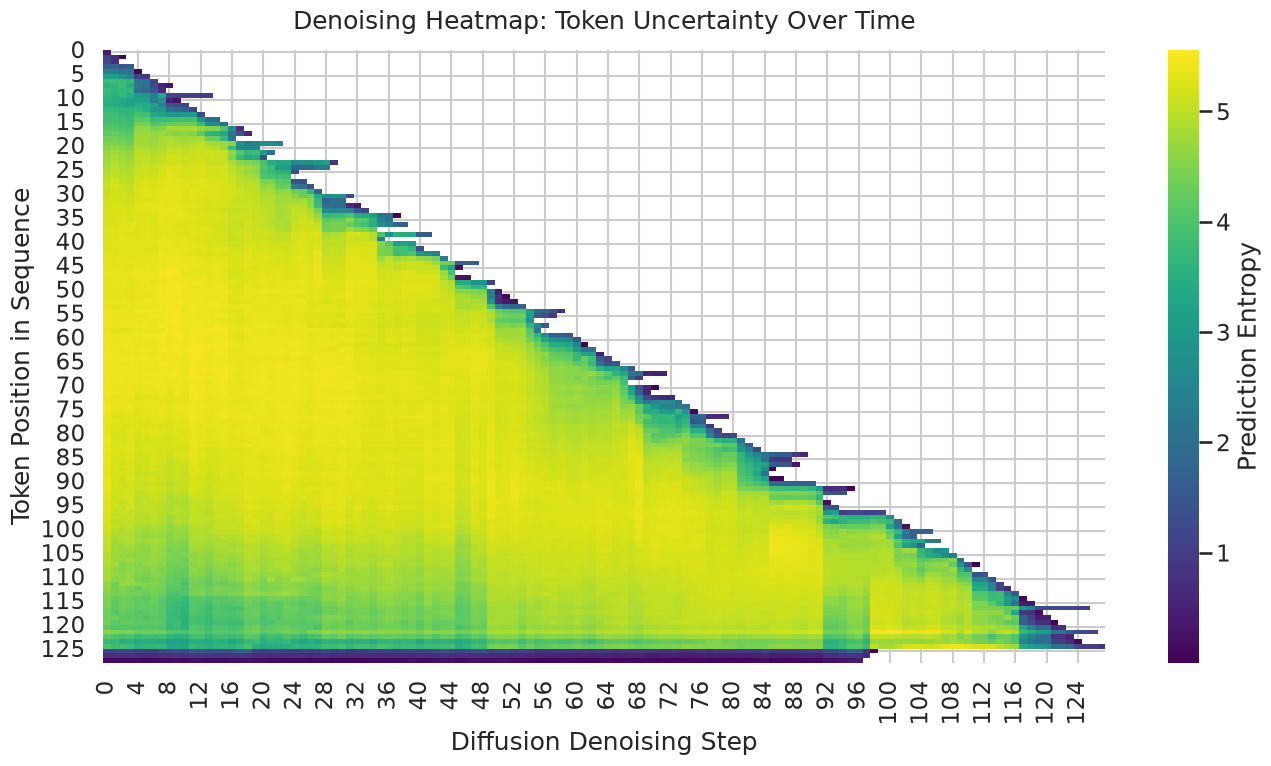

Saved denoising_heatmap.png


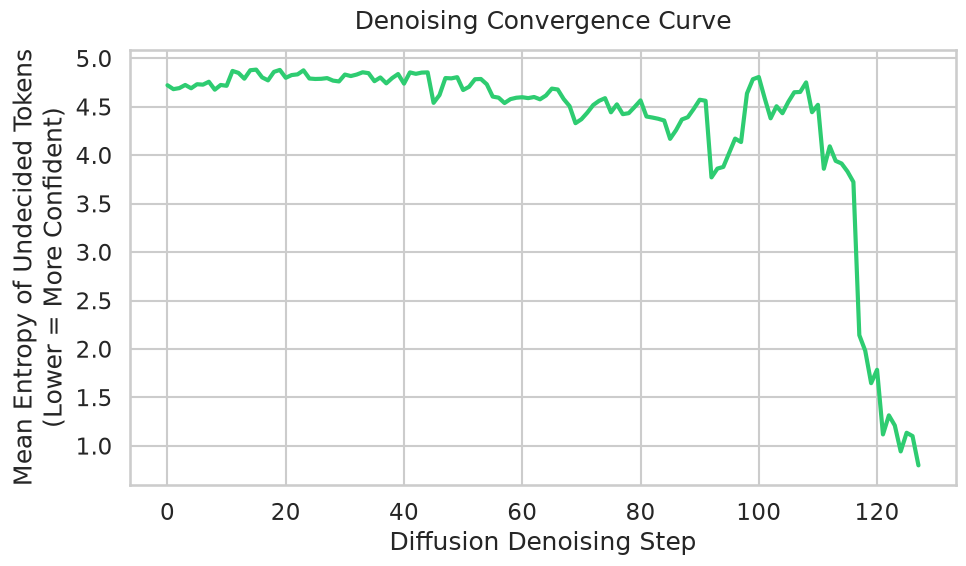

Saved convergence_curve.png


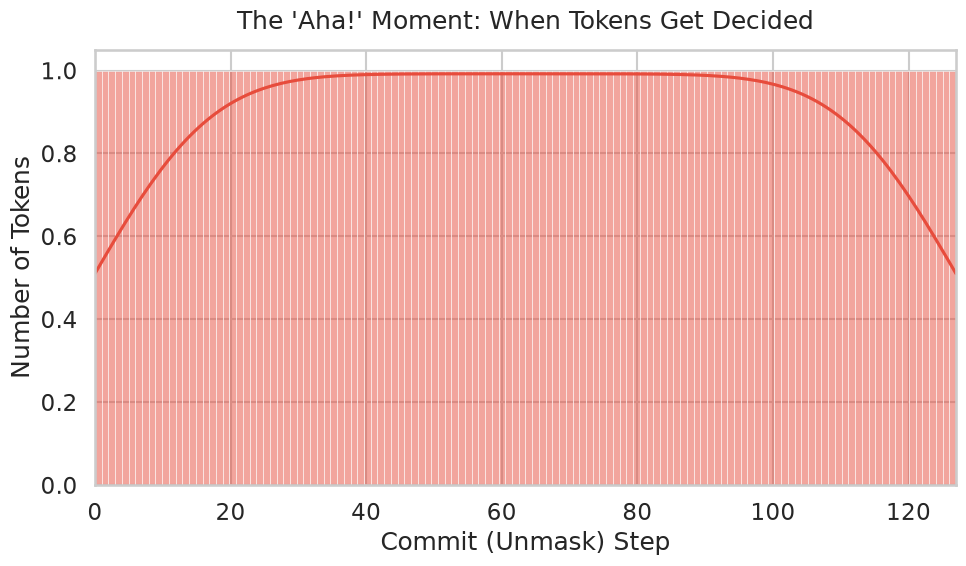

Saved aha_moment.png


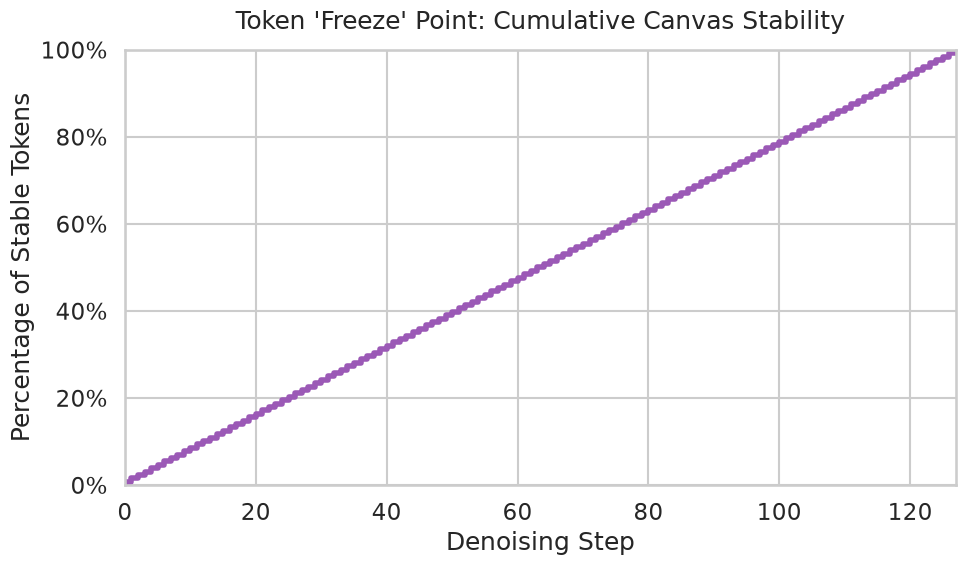

Saved freeze_curve.png
No router entropy captured (dense model) -- skipping router correlation plot.


In [10]:
# =====================================================================================
# 7. EXAMPLE DRIVER   >>> CUSTOMIZE the model-loading block for your model <<<
# =====================================================================================
if __name__ == "__main__":
    import torch
    from transformers import AutoModel, AutoTokenizer

    # ---------------------------------------------------------------------------------
    # >>> CUSTOMIZE: load YOUR diffusion LLM. Example uses LLaDA-8B (dense, real).
    #     For a different model, swap the id/class and build the matching spec.
    # ---------------------------------------------------------------------------------
    MODEL_ID = "GSAI-ML/LLaDA-8B-Instruct"
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
    model = AutoModel.from_pretrained(
        MODEL_ID, trust_remote_code=True, torch_dtype=torch.bfloat16
    ).cuda().eval()

    spec = spec_for_llada(gen_length=128, steps=128, block_length=32, temperature=0.0)

    # ---------------------------------------------------------------------------------
    # >>> CUSTOMIZE: your prompt. LLaDA-Instruct expects its chat template.
    # ---------------------------------------------------------------------------------
    messages = [{"role": "user", "content": "Explain the concept of entropy in physics."}]
    prompt = tokenizer.apply_chat_template(messages, add_generation_prompt=True, tokenize=False)
    prompt_ids = tokenizer(prompt, return_tensors="pt")["input_ids"]

    # ---- Backend A (recommended): correct, mask-aware extraction ----
    df = run_controlled_denoising(model, tokenizer, prompt_ids, spec)
    df.to_csv("diffusion_entropy_results.csv", index=False)
    print("Extracted:", df.shape)

    # ---- Plots ----
    DiffusionPlots.denoising_heatmap(df, mask_aware=True)
    DiffusionPlots.convergence_curve(df)
    DiffusionPlots.aha_moment_histogram(df)
    DiffusionPlots.freeze_curve(df)
    DiffusionPlots.router_correlation(df)   # auto-skips for dense LLaDA

In [11]:
#%pip install "transformers<4.45.0"